In [2]:
import numpy as np
import pandas as  pd

In [3]:
data=pd.read_csv("/home/harihara-suthan-s/ML-based-approach-to-Ebbinghaus-forgetting-curve/datasets collected/ebbinghaus_combined_2600_rows.csv")
data.describe()

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,S_true,retention_percentage
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,52.015231,1.862308,6.382500,5.271538,69.310769,150.395969,55.406408
std,63.945629,1.829676,1.386908,2.158610,36.482197,363.263691,33.000925
min,0.500000,0.000000,2.000000,1.000000,5.000000,10.130000,0.000000
25%,13.300000,0.000000,5.500000,4.000000,42.000000,27.157500,25.207500
50%,31.700000,1.000000,6.400000,5.000000,62.000000,50.275000,61.490000
75%,67.075000,3.000000,7.300000,7.000000,89.000000,127.617500,85.100000
max,720.000000,9.000000,10.000000,10.000000,180.000000,5115.410000,100.000000


In [4]:
data.describe(include='all')

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,S_true,retention_percentage
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600,2600.000000,2600.000000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,morning,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,855,NaN,NaN
mean,52.015231,1.862308,6.382500,5.271538,69.310769,NaN,150.395969,55.406408
std,63.945629,1.829676,1.386908,2.158610,36.482197,NaN,363.263691,33.000925
min,0.500000,0.000000,2.000000,1.000000,5.000000,NaN,10.130000,0.000000
25%,13.300000,0.000000,5.500000,4.000000,42.000000,NaN,27.157500,25.207500
50%,31.700000,1.000000,6.400000,5.000000,62.000000,NaN,50.275000,61.490000
75%,67.075000,3.000000,7.300000,7.000000,89.000000,NaN,127.617500,85.100000


In [5]:
time_mapping = {
    "morning": 0,
    "afternoon": 1,
    "evening": 2,
    "night": 3
}

data["session_time"] = data["session_time"].map(time_mapping)

In [6]:
data.describe(include='all')

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,S_true,retention_percentage
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,52.015231,1.862308,6.382500,5.271538,69.310769,1.283077,150.395969,55.406408
std,63.945629,1.829676,1.386908,2.158610,36.482197,1.099802,363.263691,33.000925
min,0.500000,0.000000,2.000000,1.000000,5.000000,0.000000,10.130000,0.000000
25%,13.300000,0.000000,5.500000,4.000000,42.000000,0.000000,27.157500,25.207500
50%,31.700000,1.000000,6.400000,5.000000,62.000000,1.000000,50.275000,61.490000
75%,67.075000,3.000000,7.300000,7.000000,89.000000,2.000000,127.617500,85.100000
max,720.000000,9.000000,10.000000,10.000000,180.000000,3.000000,5115.410000,100.000000


In [7]:
data.head(5)

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,S_true,retention_percentage
0,41.2,0,5.1,2,52,1,25.93,25.26
1,79.1,0,7.1,6,50,3,20.69,3.57
2,69.0,4,6.9,7,50,2,195.88,67.39
3,8.5,0,7.7,7,102,1,25.38,75.28
4,8.3,0,5.5,3,97,0,29.35,75.43


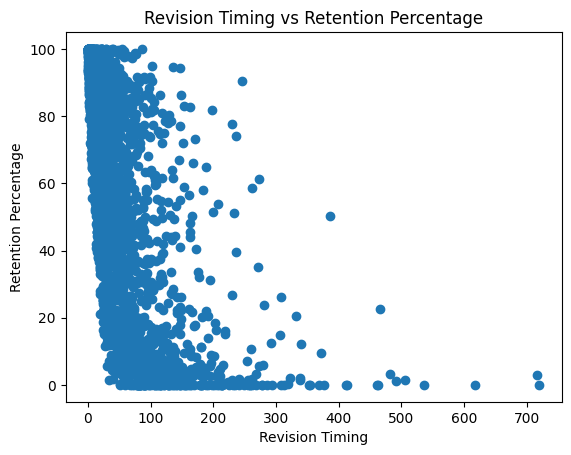

In [13]:
import matplotlib.pyplot as plt

plt.scatter(data["revision_timing"], data["retention_percentage"])
plt.xlabel("Revision Timing")
plt.ylabel("Retention Percentage")
plt.title("Revision Timing vs Retention Percentage")   
plt.show()

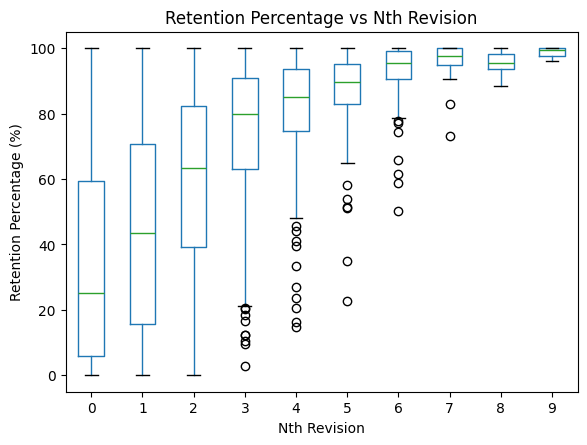

In [16]:
data.boxplot(
    column="retention_percentage",
    by="nth_revision",
    grid=False
)

plt.title("Retention Percentage vs Nth Revision")
plt.suptitle("")  # removes default pandas subtitle
plt.xlabel("Nth Revision")
plt.ylabel("Retention Percentage (%)")

plt.show()

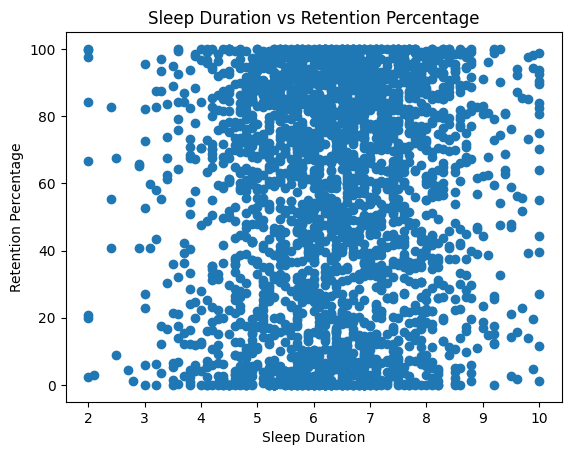

In [17]:
plt.scatter(data["sleep_duration"], data["retention_percentage"])
plt.xlabel("Sleep Duration")
plt.ylabel("Retention Percentage")
plt.title("Sleep Duration vs Retention Percentage")
plt.show()

In [19]:
print(data["sleep_duration"].corr(data["retention_percentage"]))

0.07275269892839409


In [20]:
print(data["revision_timing"].corr(data["retention_percentage"]))
print(data["session_time"].corr(data["retention_percentage"]))  
print(data["sleep_duration"].corr(data["retention_percentage"]))  
print(data["nth_revision"].corr(data["retention_percentage"]))
print(data["topic_difficulty"].corr(data["retention_percentage"]))

-0.5715827058673968
-0.04406335097419791
0.07275269892839409
0.5822566941409297
-0.060355087507521256


In [21]:
print(type(data))

<class 'pandas.DataFrame'>


In [23]:
data.to_csv("/home/harihara-suthan-s/ML-based-approach-to-Ebbinghaus-forgetting-curve/training/ebbinghaus_combined_2600_rows_cleaned.csv", index=False)